Estratégia:

Fonte dos Dados: Vamos ignorar os arquivos de treino e validação originais por conterem apenas dados não-anômalos. Usaremos o arquivo labelled_testing_data.csv como nossa única fonte de dados, pois é o único que contém ambas as classes (benigno e malicioso).

Nova Divisão de Dados: Dividiremos este arquivo em um novo conjunto de treino (80%) e um novo conjunto de teste (20%). Desta forma, teremos anomalias em ambos os conjuntos para treinar e avaliar o modelo.

Balanceamento de Classes: O novo conjunto de treino ainda será extremamente desbalanceado. Portanto, aplicaremos a técnica SMOTE para criar um conjunto de treino final balanceado, assim como foi feito no dataset anterior.

Engenharia de Features e Modelagem: Seguiremos com o RandomForestClassifier e aplicaremos as etapas de engenharia de features que planejamos.

In [1]:
# --- Importações Essenciais ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm.notebook import tqdm

# --- Importações do Scikit-learn e Imbalanced-learn ---
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    average_precision_score
)

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)
pd.set_option('display.max_columns', 50)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# --- Definição dos Caminhos ---
data_path = '../../data/raw/BETH'
test_filename = 'labelled_testing_data.csv'
full_path = os.path.join(data_path, test_filename)

# --- Carregamento do Dataset ---
try:
    df = pd.read_csv(full_path)
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado em {os.path.abspath(full_path)}")

# --- Preparação da Variável Alvo ---
df['out'] = df['evil']
df.drop(columns=['sus', 'evil'], inplace=True)

# --- Divisão simples em Treino (80%) e Teste (20%) ---
X = df.drop('out', axis=1)
y = df['out']

# Primeiro, separamos o conjunto de teste final (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Agora, dividimos o restante em treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)


print("Divisão de dados em Treino e Teste concluída:")
print(f"Treino (X, y): \t{X_train.shape}, {y_train.shape}")
print(f"Teste (X, y):  \t{X_test.shape}, {y_test.shape}")

Dataset carregado com sucesso!
Divisão de dados em Treino e Teste concluída:
Treino (X, y): 	(113379, 14), (113379,)
Teste (X, y):  	(37794, 14), (37794,)


In [3]:
# --- Engenharia de Features (Pré-Pipeline) ---
def create_time_features(data):
    df = data.copy()
    df = df.sort_values(by=['hostName', 'timestamp'])
    df['time_diff'] = df.groupby('hostName')['timestamp'].diff().fillna(0)
    return df

print("Aplicando engenharia de features de tempo...")
X_train = create_time_features(X_train)
X_val = create_time_features(X_val)
X_test = create_time_features(X_test)
print("Engenharia de features de tempo concluída.")

# --- Definição do Pipeline de Pré-processamento ---
numeric_features = ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'argsNum', 'returnValue', 'time_diff']
categorical_features = ['processName', 'hostName', 'eventName']
drop_features = ['mountNamespace', 'stackAddresses', 'args']

numeric_transformer = StandardScaler()
# Reduzimos o max_categories para garantir que não haja erro de memória
categorical_transformer = OneHotEncoder(handle_unknown='ignore', max_categories=20, sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('drop', 'drop', drop_features)
    ],
    remainder='passthrough'
)

# --- Aplicação do Pré-processador ---
print("\nAplicando o pré-processador aos dados...")
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
X_val_proc = preprocessor.transform(X_val)

print("Shapes após pré-processamento:")
print("X_train_proc:", X_train_proc.shape)
print("X_val_proc:  ", X_val_proc.shape)
print("X_test_proc:  ", X_test_proc.shape)

Aplicando engenharia de features de tempo...
Engenharia de features de tempo concluída.

Aplicando o pré-processador aos dados...
Shapes após pré-processamento:
X_train_proc: (113379, 50)
X_val_proc:   (37794, 50)
X_test_proc:   (37794, 50)


In [4]:
# --- Aplicação do SMOTE ---
# Aplicamos o SMOTE apenas no conjunto de treino para a fase de tuning

print("Balanceando o conjunto de treino com SMOTE...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_proc, y_train)

print(f"Formato do treino (antes do SMOTE): {X_train_proc.shape}")
print(f"Formato do treino (depois do SMOTE): {X_train_resampled.shape}")
print("\nDistribuição do alvo no treino (depois do SMOTE):")
print(pd.Series(y_train_resampled).value_counts())

Balanceando o conjunto de treino com SMOTE...
Formato do treino (antes do SMOTE): (113379, 50)
Formato do treino (depois do SMOTE): (190116, 50)

Distribuição do alvo no treino (depois do SMOTE):
out
0    95058
1    95058
Name: count, dtype: int64


In [5]:
# --- Definição da Grade de Hiperparâmetros ---
# Vamos testar diferentes configurações para o RandomForestClassifier

# Para um teste mais rápido, a grade pode ser pequena.
# Para um resultado mais robusto, mais valores podem ser adicionados.
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': [None, 'balanced']
}
results_list = []
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print("Grade de hiperparâmetros definida.")

Grade de hiperparâmetros definida.


In [6]:
# --- Execução do RandomizedSearchCV ---
# 'n_iterations' define o número de combinações de parâmetros a serem testadas.
n_iterations = 10

print(f"Iniciando busca manual com validação cruzada de {n_splits} folds...")

# --- Loop Externo: Hiperparâmetros ---
# Usamos tqdm para visualizar o progresso do loop externo
for n_est in tqdm(param_grid['n_estimators'], desc="n_estimators"):
    for m_depth in param_grid['max_depth']:
        for m_leaf in param_grid['min_samples_leaf']:
            for c_weight in param_grid['class_weight']:
                
                fold_scores = []
                # --- Loop Interno: Folds de Validação Cruzada ---
                for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_proc, y_train)):
                    
                    # 1. Dividir os dados para este fold
                    X_train_fold, X_val_fold = X_train_proc[train_idx], X_train_proc[val_idx]
                    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

                    # 2. Aplicar SMOTE APENAS na porção de treino deste fold
                    smote = SMOTE(random_state=42)
                    X_train_fold_res, y_train_fold_res = smote.fit_resample(X_train_fold, y_train_fold)
                    
                    # 3. Treinar o modelo
                    model = RandomForestClassifier(
                        n_estimators=n_est, max_depth=m_depth, min_samples_leaf=m_leaf,
                        class_weight=c_weight, random_state=42, n_jobs=-1
                    )
                    model.fit(X_train_fold_res, y_train_fold_res)
                    
                    # 4. Avaliar no conjunto de validação do fold (sem SMOTE)
                    y_pred_fold = model.predict(X_val_fold)
                    fold_scores.append(f1_score(y_val_fold, y_pred_fold, average='macro'))

                # Calcular a média dos scores dos folds
                avg_score = np.mean(fold_scores)
                
                results_list.append({
                    'n_estimators': n_est, 'max_depth': m_depth, 'min_samples_leaf': m_leaf,
                    'class_weight': c_weight, 'f1_macro_cv': avg_score
                })

print("\nBusca manual concluída!")

Iniciando busca manual com validação cruzada de 3 folds...


n_estimators:   0%|          | 0/3 [00:00<?, ?it/s]


Busca manual concluída!



Melhores parâmetros encontrados (média da validação cruzada):
{'n_estimators': 300, 'max_depth': 20.0, 'min_samples_leaf': 1, 'class_weight': 'balanced', 'f1_macro_cv': 0.5005957253107832}
Preparando dados finais de treino (treino + validação)...
Balanceando o conjunto de dados final com SMOTE...

Treinando o modelo final...
--- Melhores parâmetros encontrados na busca manual ---
{'n_estimators': 300, 'max_depth': 20.0, 'min_samples_leaf': 1, 'class_weight': 'balanced'}

Treinando modelo para otimização de limiar...
Calculando probabilidades no conjunto de validação...

Melhor Limiar de Decisão encontrado no conjunto de validação: 0.0608


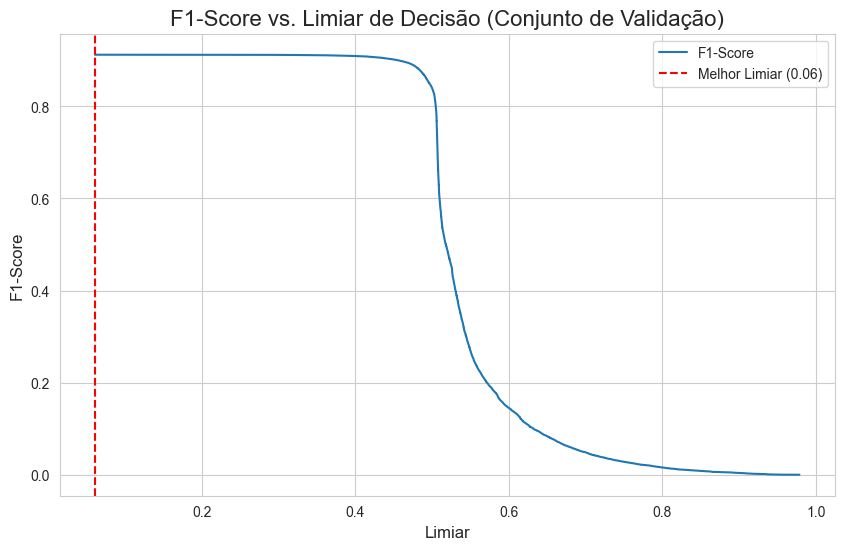

In [7]:
# --- Treino e Avaliação Final ---
# --- Analisar Resultados ---
results_df = pd.DataFrame(results_list)
best_params_row = results_df.sort_values(by='f1_macro_cv', ascending=False).iloc[0]
best_params = best_params_row.to_dict()
print("\nMelhores parâmetros encontrados (média da validação cruzada):")
print(best_params)

# 1. Preparar os dados finais de treino (treino + validação)
print("Preparando dados finais de treino (treino + validação)...")
X_train_val = np.concatenate([X_train_proc, X_val_proc])
y_train_val = np.concatenate([y_train, y_val])

print("Balanceando o conjunto de dados final com SMOTE...")
X_train_val_resampled, y_train_val_resampled = smote.fit_resample(X_train_val, y_train_val)

# 2. Criar o modelo final com os melhores parâmetros
print("\nTreinando o modelo final...")
# Remover a métrica de avaliação da lista de parâmetros
best_params.pop('f1_macro_cv') # Remover a métrica de avaliação da lista de parâmetros
print("--- Melhores parâmetros encontrados na busca manual ---")
print(best_params)

# Corrigir o valor de max_depth se ele for nan
if pd.isna(best_params.get('max_depth')):
    best_params['max_depth'] = None
else:
    # Garantir que seja um inteiro se não for None
    best_params['max_depth'] = int(best_params['max_depth'])
    
# Garantir que outros parâmetros sejam inteiros
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])

# 1. Treinar um modelo com os melhores parâmetros no conjunto de treino já balanceado da Célula 4
print("\nTreinando modelo para otimização de limiar...")
model_for_tuning = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
model_for_tuning.fit(X_train_resampled, y_train_resampled)

# 2. Obter probabilidades no conjunto de validação (que é desbalanceado e nunca viu SMOTE)
print("Calculando probabilidades no conjunto de validação...")
y_probs_val = model_for_tuning.predict_proba(X_val_proc)[:, 1]

# 3. Encontrar o melhor limiar que maximiza o F1-Score
precision, recall, thresholds = precision_recall_curve(y_val, y_probs_val)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]

print(f"\nMelhor Limiar de Decisão encontrado no conjunto de validação: {best_threshold:.4f}")

# Plotar a curva F1-Score vs. Limiar
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.title("F1-Score vs. Limiar de Decisão (Conjunto de Validação)", fontsize=16)
plt.xlabel("Limiar", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.legend()
plt.show()

Preparando dados finais de treino (combinando treino + validação)...
Formato do conjunto combinado: (151173, 50)
Balanceando o conjunto de dados combinado com SMOTE...
Formato do conjunto final para treino: (253490, 50)

Treinando o modelo final...
Treino final concluído.

Avaliando no conjunto de teste...

--- Relatório de Classificação Final (com Limiar Otimizado) ---
               precision    recall  f1-score   support

  Benigno (0)       0.00      0.00      0.00      6107
Malicioso (1)       0.84      1.00      0.91     31687

     accuracy                           0.84     37794
    macro avg       0.42      0.50      0.46     37794
 weighted avg       0.70      0.84      0.76     37794


ROC AUC (Teste): 0.5044

--- Matriz de Confusão Final ---


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

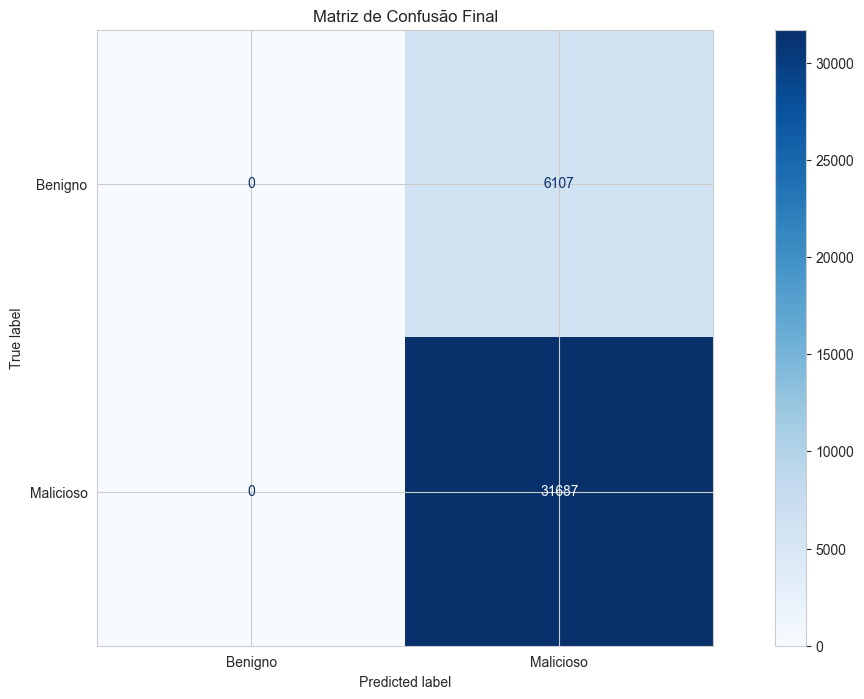

In [8]:
# --- Treino e Avaliação do Modelo Final ---

# 1. Preparar os dados finais de treino (combinando treino + validação)
print("Preparando dados finais de treino (combinando treino + validação)...")
X_train_val = np.concatenate([X_train_proc, X_val_proc])
y_train_val = np.concatenate([y_train, y_val])
print(f"Formato do conjunto combinado: {X_train_val.shape}")

# 2. Balancear este conjunto combinado com SMOTE
print("Balanceando o conjunto de dados combinado com SMOTE...")
smote_final = SMOTE(random_state=42)
X_train_val_resampled, y_train_val_resampled = smote_final.fit_resample(X_train_val, y_train_val)
print(f"Formato do conjunto final para treino: {X_train_val_resampled.shape}")

# 3. Criar e treinar o modelo final com os melhores parâmetros
print("\nTreinando o modelo final...")
final_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
final_model.fit(X_train_val_resampled, y_train_val_resampled)
print("Treino final concluído.")

# 4. Avaliação no Conjunto de Teste
print("\nAvaliando no conjunto de teste...")
y_pred_probs_test = final_model.predict_proba(X_test_proc)[:, 1]

# Aplicar o limiar que encontramos na Célula 6 usando os dados de VALIDAÇÃO
y_pred_tuned_test = (y_pred_probs_test >= best_threshold).astype(int)

# --- Relatório Final ---
print("\n--- Relatório de Classificação Final (com Limiar Otimizado) ---")
print(classification_report(y_test, y_pred_tuned_test, target_names=['Benigno (0)', 'Malicioso (1)']))

# Calcular ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs_test)
print(f"\nROC AUC (Teste): {roc_auc:.4f}")

# --- Matriz de Confusão Final ---
print("\n--- Matriz de Confusão Final ---")
cm = confusion_matrix(y_test, y_pred_tuned_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Malicioso'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão Final")
plt.show()

In [9]:
env = globals()

# helpers para lidar com nomes diferentes
X_test_candidates = ['X_test', 'X_test_pca', 'X_test_proc']
X_train_candidates = ['X_train', 'X_train_pca', 'X_train_proc']
y_test_candidates = ['y_test', 'y_test_proc']
y_train_candidates = ['y_train']

def find_name(cands):
    for c in cands:
        if c in env:
            return c
    return None

X_test_name = find_name(X_test_candidates)
X_train_name = find_name(X_train_candidates)
y_test_name = find_name(y_test_candidates)
y_train_name = find_name(y_train_candidates)

print("Detectadas variáveis:")
print(" X_test:", X_test_name)
print(" X_train:", X_train_name)
print(" y_test:", y_test_name)
print(" y_train:", y_train_name)
print()

# 1) checar distribuições de classes
if y_train_name:
    y_train_arr = env[y_train_name]
    print("Distribuição em y_train:", pd.Series(y_train_arr).value_counts().to_dict())
if y_test_name:
    y_test_arr = env[y_test_name]
    print("Distribuição em y_test:", pd.Series(y_test_arr).value_counts().to_dict())

# 2) checar se modelo existe e prever no test, analisar probabilidades
model_names = ['final_model','best_pipeline','model_for_tuning','gs','gs.best_estimator_']
model = None
for n in ['final_model','best_pipeline','model_for_tuning','gs','best_estimator','best_model']:
    if n in env and env[n] is not None:
        model = env[n]
        mn = n
        break

if model is None:
    print("\n[AVISO] Não detectei um modelo treinado nas variáveis comuns. Indique o nome ou treine antes deste diagnóstico.")
else:
    print("\nModelo detectado em variável:", mn, " — tipo:", type(model))
    # predict_proba e predict no test
    if X_test_name and y_test_name:
        X_test_arr = env[X_test_name]
        y_test_arr = env[y_test_name]
        try:
            probs = model.predict_proba(X_test_arr)[:,1]
            preds_proba = (probs >= 0.5).astype(int)
            print("\nProbabilidades (test): min, 25%, median, 75%, max =",
                  np.min(probs), np.percentile(probs,25), np.median(probs), np.percentile(probs,75), np.max(probs))
            # quantize for quick view
            unique_probs = np.unique(np.round(probs, 3))
            print("Unique probs (sample):", unique_probs[:10], ("..." if unique_probs.size>10 else ""))
        except Exception as e:
            print("[WARN] predict_proba falhou:", e)
            probs = None
            try:
                preds_proba = model.predict(X_test_arr)
            except Exception as e2:
                print("[ERRO] predict também falhou:", e2)
                preds_proba = None

        # predict
        try:
            preds = model.predict(X_test_arr)
        except Exception as e:
            print("[WARN] predict falhou:", e)
            preds = None

        if preds is not None:
            print("\nClassification report (threshold 0.5 / model.predict):")
            print(classification_report(y_test_arr, preds, digits=4))
            print("Confusion matrix:\n", confusion_matrix(y_test_arr, preds))

        if probs is not None:
            try:
                auroc = roc_auc_score(y_test_arr, probs)
                print(f"\nROC AUC (test probs): {auroc:.4f}")
            except Exception as e:
                print("[WARN] ROC AUC não pôde ser calculado:", e)
    else:
        print("[INFO] Não há X_test/y_test detectados para avaliação completa.")

Detectadas variáveis:
 X_test: X_test
 X_train: X_train
 y_test: y_test
 y_train: y_train

Distribuição em y_train: {1: 95058, 0: 18321}
Distribuição em y_test: {1: 31687, 0: 6107}

Modelo detectado em variável: final_model  — tipo: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
[WARN] predict_proba falhou: could not convert string to float: 'systemd'
[ERRO] predict também falhou: could not convert string to float: 'systemd'
[WARN] predict falhou: could not convert string to float: 'systemd'


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [10]:
X_test_obj = globals().get('X_test')
print("Tipo de X_test:", type(X_test_obj))

if isinstance(X_test_obj, pd.DataFrame):
    # procurar valores não-numéricos
    non_numeric_cols = []
    for c in X_test_obj.columns:
        # vê se coluna é numérica segundo pandas
        if not pd.api.types.is_numeric_dtype(X_test_obj[c]):
            non_numeric_cols.append(c)
    print("Colunas não-numéricas em X_test (pandas detect):", non_numeric_cols[:50])
    # procurar ocorrências específicas da string 'systemd'
    occurs = (X_test_obj == 'systemd')
    if occurs.values.any():
        loc = np.where(occurs.values)
        rows = loc[0][:10]
        cols = X_test_obj.columns[loc[1][:10]].tolist()
        print("Exemplo de posições com 'systemd' (até 10):", list(zip(rows, cols)) )
else:
    # X_test é numpy: procurar strings embutidos (object dtype)
    try:
        arr = np.asarray(X_test_obj)
        print("X_test dtype:", arr.dtype, "shape:", arr.shape)
        if arr.dtype == object:
            print("X_test contém dtype object; procurando 'systemd'...")
            # cuidado: busca pode ser custosa
            hits = np.argwhere(arr == 'systemd')
            print("Exemplos de hits (até 10):", hits[:10])
        else:
            print("X_test é numérico (dtype não-object).")
    except Exception as e:
        print("Erro ao inspecionar X_test:", e)

Tipo de X_test: <class 'pandas.core.frame.DataFrame'>
Colunas não-numéricas em X_test (pandas detect): ['processName', 'hostName', 'eventName', 'stackAddresses', 'args']
Exemplo de posições com 'systemd' (até 10): [(np.int64(0), 'processName'), (np.int64(49), 'processName'), (np.int64(50), 'processName'), (np.int64(51), 'processName'), (np.int64(52), 'processName'), (np.int64(53), 'processName'), (np.int64(54), 'processName'), (np.int64(55), 'processName'), (np.int64(56), 'processName'), (np.int64(57), 'processName')]
